<a href="https://colab.research.google.com/github/nathaliakpalma-lab/Mortalidade_no_Brasil/blob/main/Mortalidade_no_Brasil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Importação da Base de Dados e das Bibliotecas**

In [1]:
# Importar a base de dados contendo o número de óbitos por capítulo CID-10 por ano
from google.colab import files
uploaded = files.upload()

Saving Causa_obt_2000_2020.csv to Causa_obt_2000_2020.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **2. Leitura, Exploração e Tratamento da Base**

In [3]:
causa_obt_df = pd.read_csv('Causa_obt_2000_2020.csv')
causa_obt_df.head()

,Capítulo CID-10,2000,2020
0,I. Algumas doenças infecciosas e parasitárias,44515,267287
1,II. Neoplasias (tumores),120517,229300
2,III. Doenças sangue órgãos hemat e transt imun...,4800,6596
3,IV. Doenças endócrinas nutricionais e metaból...,47281,92749
4,V. Transtornos mentais e comportamentais,6139,17168


In [4]:
causa_obt_df.tail()

,Capítulo CID-10,2000,2020
18,XIX. Lesões enven e alg out conseq causas exte...,-,-
19,XX. Causas externas de morbidade e mortalidade,118397,146038
20,XXI. Contatos com serviços de saúde,-,-
21,XXII.Códigos para propósitos especiais,-,-
22,Total,946686,1556824


Utilizando os comandos acima, é possível visualizar quantas linhas compõem o data frame e quais os títulos das colunas, informações importantes para as análises futuras.

In [5]:
causa_obt_df.dtypes

,0
Capítulo CID-10,object
2000,object
2020,object


Com o comando .dtypes foi possível observar que as colunas '2000' e '2020' não estão sendo lidas como numéricas, o que impossibilita as análises. Por isso, é necessário transformá-las usando o código abaixo, que converte valores não numéricos em 0.

In [6]:
# Primeiro a conversão das colunas em valores numéricos, transformando os erros em NA. Depois, a conversão para valores inteiros e transformação dos NAs em 0.
causa_obt_df['2000'] = pd.to_numeric(causa_obt_df['2000'], errors='coerce')
causa_obt_df['2020'] = pd.to_numeric(causa_obt_df['2020'], errors='coerce')
causa_obt_df['2000'] = causa_obt_df['2000'].fillna(0).astype(int)
causa_obt_df['2020'] = causa_obt_df['2020'].fillna(0).astype(int)

In [7]:
causa_obt_df.dtypes

,0
Capítulo CID-10,object
2000,int64
2020,int64


# **3. Análises Iniciais do Banco**

## 3.1 Principais causas de morte em 2000 e em 2020

In [8]:
# Identificar o maior valor da coluna do ano 2000 e do ano 2020, desconsiderando a última linha (que apresenta os valores totais). Com .loc é possível visualizar
# a linha completa associada aos valores máximos encontrados.
principal_2000 = causa_obt_df.iloc[:-1]['2000'].idxmax()
principal_2020 = causa_obt_df.iloc[:-1]['2020'].idxmax()
print(causa_obt_df.loc[principal_2000])
print(causa_obt_df.loc[principal_2020])

Capítulo CID-10    IX.  Doenças do aparelho circulatório
2000                                              260603
2020                                              357741
Name: 8, dtype: object
Capítulo CID-10    IX.  Doenças do aparelho circulatório
2000                                              260603
2020                                              357741
Name: 8, dtype: object


Com a análise acima, é possível notar que tanto em 2000 quanto em 2020, as principais causas de morte foram doenças do aparelho circulatório. Entretanto, ainda é preciso entender se o nível de impacto dessas causas se manteve o mesmo, aumentou ou diminuiu após esse período, além de analisar outras causas de óbito que podem ser relevantes. Para isso, é interessante realizar uma análise de transição epidemiológica.

## 3.2 Transição epidemiológica: perfil das causas de óbito de 2000 vs 2020

Para analisar a transição epidemiológica entre os anos em questão, não basta comparar os valores brutos de cada ano, afinal variáveis como o crescimento populacional podem impactar a análise. Assim, é mais interessante avaliar o quanto cada causa (Capítulo CID-10) impactou no total de óbitos daquele ano. Uma forma de realizar essa avaliação é comparando os valores em porcentagem:

In [9]:
# Criar duas novas colunas, uma para cada ano, com os valores de porcentagem de cada causa de óbito em relação ao total de óbitos.
if '2000' in causa_obt_df.columns:
    causa_obt_df['2000(%)'] = (causa_obt_df['2000'] / 946686) * 100
if '2020' in causa_obt_df.columns:
    causa_obt_df['2020(%)'] = (causa_obt_df['2020'] / 1556824) * 100
causa_obt_df.head()


,Capítulo CID-10,2000,2020,2000(%),2020(%)
0,I. Algumas doenças infecciosas e parasitárias,44515,267287,4.702193,17.168736
1,II. Neoplasias (tumores),120517,229300,12.730409,14.728704
2,III. Doenças sangue órgãos hemat e transt imun...,4800,6596,0.507032,0.423683
3,IV. Doenças endócrinas nutricionais e metaból...,47281,92749,4.994370,5.957578
4,V. Transtornos mentais e comportamentais,6139,17168,0.648473,1.102758


Com os novos dados, é possível construir um gráfico para visualização e comparação dos perfis de causas de óbito nos dois anos.

### 3.2.1 Visualização: Comparativo de Causas de Óbito (2000 e 2020)

In [10]:
# Remover a última linha do df (valores totais) para não impactar no gráfico
causa_obt_df.drop(causa_obt_df.index[-1], inplace=True)

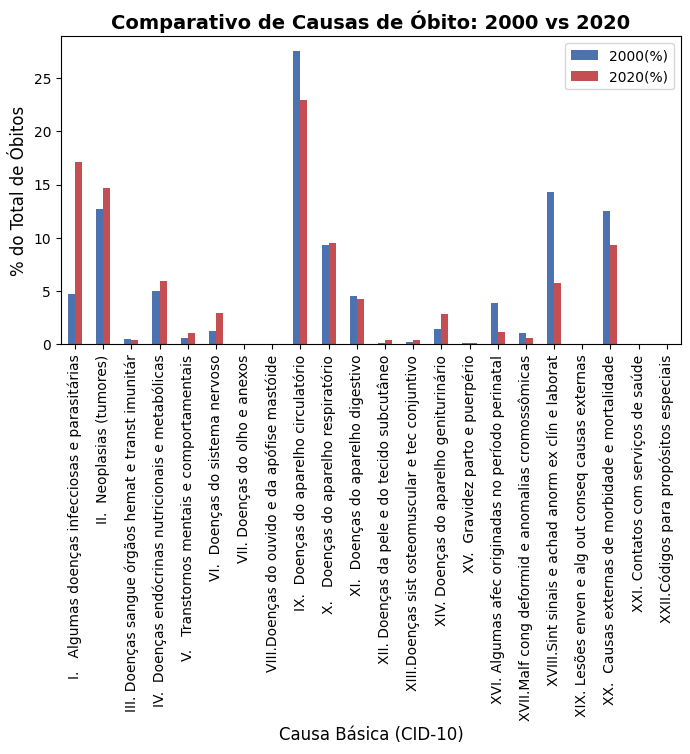

In [11]:
if 'Capítulo CID-10' in causa_obt_df.columns:
# Definindo o índice (eixo X)
  causa_obt_df.set_index('Capítulo CID-10', inplace=True)

# Criando o gráfico de barras agrupadas, selecionando apenas as colunas desejadas e definindo as configurações
ax = causa_obt_df[['2000(%)','2020(%)']].plot(kind='bar', figsize=(8, 4), color=['#4C72B0', '#C44E52'])
plt.title('Comparativo de Causas de Óbito: 2000 vs 2020', fontsize=14, fontweight='bold')
plt.xlabel('Causa Básica (CID-10)', fontsize=12)
plt.ylabel('% do Total de Óbitos', fontsize=12)

plt.show()

Com o gráfico acima, fica nítido como as doenças do aparelho circulatório são impactantes na mortalidade, tanto em 2000 quanto em 2020. Também é expressivo o aumento do impacto de doenças infecciosas e parasitárias em 2020 em comparação a 2000, assim como para as doenças do sistema nervoso.

## 3.3 Análise sobre o perfil de óbitos de 2020

A expectativa de vida ao nascer para o total da população brasileira tem aumentado ao longo dos anos, passando de 69,8 anos em 2000 para 75,4 anos em 2015, segundo o IBGE. A estimativa do Instituto para o ano de 2020, se o Brasil não tivesse vivenciado uma crise de mortalidade por conta da pandemia de COVID-19, seria de 76,8 anos.

Com esses dados, é possível ressaltar 3 pontos importantes para a análise do perfil de óbitos de 2020:

1- O aumento da expectativa de vida ao nascer da população total com o passar dos anos, indica um envelhecimento populacional. Com esse fenômeno, espera-se que as causas de óbito com maior impacto passem a ser, cada vez mais, aquelas mais fortemente relacionadas às pessoas de idade avançada (como infarto, AVC, neoplasias e Alzheimer) e cada vez menos causas externas e infecções, por exemplo.  
2- O ano de 2020 contou com um acontecimento inesperado e que impactou o seu perfil epidemiológico: a pandemia de COVID-19. A taxa de mortalidade em 2020 apresentou um aumento de quase 15% em relação a 2019, sendo a maior variação desde 1984. Cerca de 99% dessa variação ocorreu entre casos de óbito por causas naturais (categoria que engloba a COVID) e teve maior impacto na faixa etária de 60 anos ou mais (Fonte: IBGE). Esses dados reforçam como a pandemia impactou o perfil de óbitos, especialmente diminuindo o percentual ocupado pelas causas citadas no tópico acima (doenças no aparelho circulatório, sistema nervoso e neoplasias) e aumentando o impacto das doenças infecciosas.  
3- Observando o gráfico do tópico 3.2.1 "Comparativo de Causas de Óbito: 2000 vs 2020", é possível notar como mesmo com a influência da pandemia, as principais causas de óbito no ano de 2020 foram as doenças do aparelho circulatório. Isso reforça a importância de políticas públicas que estejam voltadas a essas causas e, principalmente, aos públicos e regiões mais afetados por elas.

[Expectativa de vida ao nascer: 2000 a 2015 - IBGE](https://brasilemsintese.ibge.gov.br/populacao/esperancas-de-vida-ao-nascer.html)

[Expectativa de vida ao nascer: 2020 (estimativa sem a COVID-19)](https://www.ibge.gov.br/novo-portal-destaques/32315-nota-sobre-as-tabuas-de-mortalidade-2020-e-a-pandemia-de-covid-19.html)

[Aumento da taxa de mortalidade em 2020 - IBGE](https://agenciadenoticias.ibge.gov.br/agencia-noticias/2012-agencia-de-noticias/noticias/32271-com-pandemia-registros-de-obitos-crescem-14-9-e-atingem-maior-patamar-da-serie)

# 4. Análises Aprofundadas e Sugestões de Ações

## 4.1 Envelhecimento populacional

Como pontuado anteriormente, com as mudanças na distribuição etária da população (vide figura abaixo), espera-se um aumento na mortalidade por DCNTs (Doenças Crônicas Não Transmissíveis), grupo no qual se enquadram as principais causas de óbitos de 2020 (doenças do aparelho circulatório) e demais causas que apresentaram um aumento significativo quando comparadas aos dados de 2000 (neoplasias, doenças do sistema nervoso, doenças endócrinas nutricionais e metabólicas).

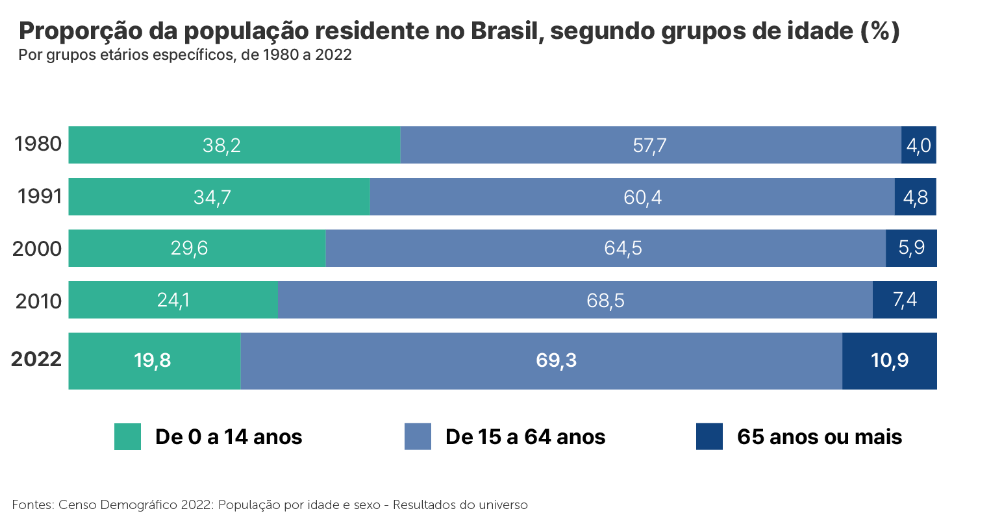

Fonte: [Distribuição etária ao longo dos anos - IBGE](https://educa.ibge.gov.br/jovens/conheca-o-brasil/populacao/18318-piramide-etaria.html)

Para ilustrar essa relação entre a prevalência de DCNTs e o envelhecimento populacional, pode-se analisar a quantidade de óbitos por faixa etária segundo a causa (Capítulo CID-10).

In [12]:
# Importar a base de dados contendo os óbitos por faixa etária segundo a causa (dados do ano de 2020)
from google.colab import files
uploaded = files.upload()

Saving Obitos_Faixa_Etaria_2020.csv to Obitos_Faixa_Etaria_2020.csv


In [13]:
obt_FE_2020_df = pd.read_csv('Obitos_Faixa_Etaria_2020.csv')
obt_FE_2020_df.head()

,Faixa Etária,Cap I,Cap II,Cap III,Cap IV,Cap V,Cap VI,Cap VII,Cap VIII,Cap IX,...,Cap XI,Cap XII,Cap XIII,Cap XIV,Cap XV,Cap XVI,Cap XVII,Cap XVIII,Cap XX,Total
0,Menor 1 ano,1381,123,128,275,2,355,2,12,279,...,307,34,10,118,-,18618,7273,830,863,31439
1,1 a 4 anos,537,456,97,125,2,414,-,1,154,...,120,15,12,68,-,24,594,275,1213,4586
2,5 a 9 anos,247,504,66,76,3,265,-,3,104,...,60,8,15,39,-,8,149,119,752,2582
3,10 a 14 anos,271,558,87,102,11,439,-,3,181,...,104,5,35,56,8,3,153,216,1445,3880
4,15 a 19 anos,650,738,132,207,75,534,-,5,549,...,178,20,70,105,172,12,149,806,11750,16642


In [14]:
obt_FE_2020_df.tail()

,Faixa Etária,Cap I,Cap II,Cap III,Cap IV,Cap V,Cap VI,Cap VII,Cap VIII,Cap IX,...,Cap XI,Cap XII,Cap XIII,Cap XIV,Cap XV,Cap XVI,Cap XVII,Cap XVIII,Cap XX,Total
9,60 a 69 anos,56996,58490,1015,19500,3085,3692,5,26,70173,...,13938,1088,963,6652,-,9,214,14964,11344,286190
10,70 a 79 anos,65803,56572,1256,24255,1918,8407,2,28,89373,...,13473,1518,1152,10043,-,11,123,16301,8987,334733
11,80 anos e mais,73371,48440,1862,29633,3509,24939,6,42,130220,...,15651,2883,2135,21142,-,28,143,30244,13178,462678
12,Idade ignorada,72,24,5,23,14,13,-,-,142,...,50,4,-,3,-,28,4,521,1380,2387
13,Total,267287,229300,6596,92749,17168,45598,24,164,357741,...,66667,6796,6128,44860,2147,18770,9673,90345,146038,1556824


In [15]:
obt_FE_2020_df.dtypes

,0
Faixa Etária,object
Cap I,int64
Cap II,int64
Cap III,int64
Cap IV,int64
Cap V,int64
Cap VI,int64
Cap VII,object
Cap VIII,object
Cap IX,int64


Novamente algumas colunas estão sendo lidas como "object", então é necessário realizar o processo de conversão

In [16]:
obt_FE_2020_df['Cap VII'] = pd.to_numeric(obt_FE_2020_df['Cap VII'], errors='coerce')
obt_FE_2020_df['Cap VIII'] = pd.to_numeric(obt_FE_2020_df['Cap VIII'], errors='coerce')
obt_FE_2020_df['Cap XIII'] = pd.to_numeric(obt_FE_2020_df['Cap XIII'], errors='coerce')
obt_FE_2020_df['Cap XV'] = pd.to_numeric(obt_FE_2020_df['Cap XV'], errors='coerce')
obt_FE_2020_df['Cap VII'] = obt_FE_2020_df['Cap VII'].fillna(0).astype(int)
obt_FE_2020_df['Cap VIII'] = obt_FE_2020_df['Cap VIII'].fillna(0).astype(int)
obt_FE_2020_df['Cap XIII'] = obt_FE_2020_df['Cap XIII'].fillna(0).astype(int)
obt_FE_2020_df['Cap XV'] = obt_FE_2020_df['Cap XV'].fillna(0).astype(int)

In [17]:
obt_FE_2020_df.dtypes

,0
Faixa Etária,object
Cap I,int64
Cap II,int64
Cap III,int64
Cap IV,int64
Cap V,int64
Cap VI,int64
Cap VII,int64
Cap VIII,int64
Cap IX,int64


### 4.1.1 Visualização: Número de óbitos por Faixa etária segundo a causa (ano de 2020)

In [18]:
# Remover a última linha e a última coluna do df (valores totais) para não impactar no gráfico
obt_FE_2020_df.drop(obt_FE_2020_df.index[-1], inplace=True)
obt_FE_2020_df.drop(columns=obt_FE_2020_df.columns[-1], inplace=True)

In [19]:
# Remover a linha da faixa "Idade ignorada" para melhorar a visualização
obt_FE_2020_df.drop(obt_FE_2020_df.index[-1], inplace=True)


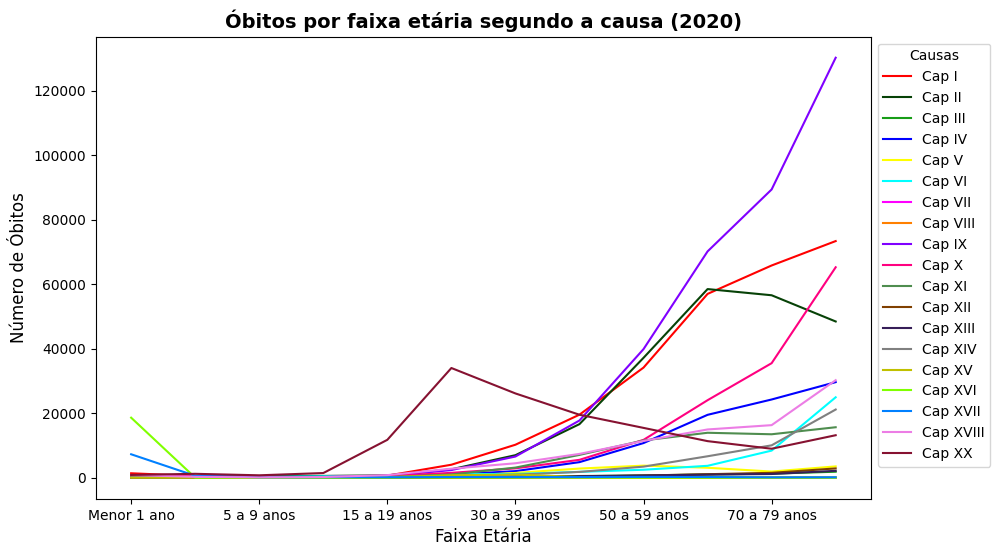

In [20]:
if 'Faixa Etária' in obt_FE_2020_df.columns:
# Definindo o índice (eixo X)
  obt_FE_2020_df.set_index('Faixa Etária', inplace=True)

# Criando o gráfico de linhas e definindo as configurações
ax = obt_FE_2020_df.plot(kind='line', figsize=(10, 6), color= ['#FF0000','#074207','#179d17','#0000FF','#FFFF00','#00FFFF','#FF00FF','#FF8000','#8000FF','#FF0080','#4f8d4f',
                                                               '#804000','#361e58','#808080','#C0C000','#80FF00','#0080FF', '#ec7de5','#861231'])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', title="Causas")

plt.title('Óbitos por faixa etária segundo a causa (2020)', fontsize=14, fontweight='bold')
plt.xlabel('Faixa Etária', fontsize=12)
plt.ylabel('Número de Óbitos', fontsize=12)

plt.show()

**Causas**:

I.   Algumas doenças infecciosas e parasitárias  
II.  Neoplasias (tumores)  
III. Doenças sangue órgãos hemat e transt imunitár  
IV.  Doenças endócrinas nutricionais e metabólicas  
V.   Transtornos mentais e comportamentais  
VI.  Doenças do sistema nervoso  
VII. Doenças do olho e anexos  
VIII.Doenças do ouvido e da apófise mastóide  
IX.  Doenças do aparelho circulatório  
X.   Doenças do aparelho respiratório  
XI.  Doenças do aparelho digestivo  
XII. Doenças da pele e do tecido subcutâneo  
XIII.Doenças sist osteomuscular e tec conjuntivo  
XIV. Doenças do aparelho geniturinário  
XV.  Gravidez parto e puerpério  
XVI. Algumas afec originadas no período perinatal  
XVII.Malf cong deformid e anomalias cromossômicas  
XVIII.Sint sinais e achad anorm ex clín e laborat    
XX.  Causas externas de morbidade e mortalidade   

Observando o gráfico acima, pode-se ressaltar 3 pontos essenciais que ilustram o envelhecimento populacional e a relação com o aumento na prevalência das DCNTs:

1- A maioria dos óbitos aconteceu na faixa acima dos 80 anos;  
2- As causas de óbito mais impactantes (também observadas no gráfico do item 3.2.1), assim como o esperado, possuem maior prevalência nas faixas acima dos 50 anos;  
3- Essas causas (Capítulos II, IV, VI, IX e X) englobam importantes DCNTs, como câncer, diabetes, Alzheimer, hipertensão e doença pulmonar obstrutiva crônica (DPOC).

### 4.1.2 Impacto da pandemia de COVID-19 nos óbitos de 2020

Como pontuado anteriormente, a pandemia impactou diretamente o perfil de óbitos do ano de 2020. Nos gráficos dos tópicos 3.2.1 e 4.1.1, é possível notar que a segunda maior causa de morte no ano foram as Doenças Infecciosas e Parasitárias, categoria na qual se enquadram as mortes por infecção por coronavírus.

O gráfico simples da quantidade de óbitos por "Algumas Doenças Infecciosas e Parasitárias" (Capítulo I da CID-10) ao longo dos anos de 2000 a 2020, demonstra o aumento expressivo desses óbitos nesse primeiro ano da pandemia:

In [21]:
from google.colab import files
uploaded = files.upload()

Saving Obitos_Do_Infec_Paras_2000_2020.csv to Obitos_Do_Infec_Paras_2000_2020.csv


In [22]:
obt_ADIP_2000_2020_df = pd.read_csv('Obitos_Do_Infec_Paras_2000_2020.csv')
obt_ADIP_2000_2020_df.head()

,Ano do Óbito,Cap I,Total
0,2000,44515,44515
1,2001,45032,45032
2,2002,45175,45175
3,2003,46533,46533
4,2004,46067,46067


In [23]:
obt_ADIP_2000_2020_df.tail()

,Ano do Óbito,Cap I,Total
17,2017,54874,54874
18,2018,54679,54679
19,2019,56666,56666
20,2020,267287,267287
21,Total,1258262,1258262


In [24]:
obt_ADIP_2000_2020_df.drop(obt_ADIP_2000_2020_df.index[-1], inplace=True)
obt_ADIP_2000_2020_df.drop(columns=obt_ADIP_2000_2020_df.columns[-1], inplace=True)

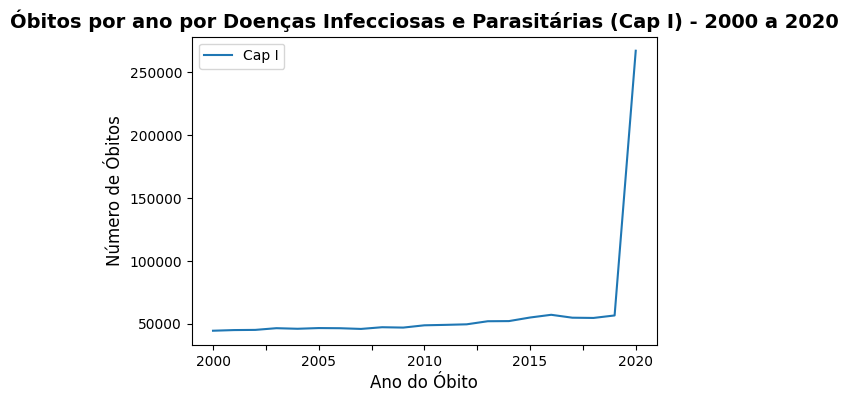

In [25]:
if 'Ano do Óbito' in obt_ADIP_2000_2020_df.columns:
  obt_ADIP_2000_2020_df.set_index('Ano do Óbito', inplace=True)

ax = obt_ADIP_2000_2020_df.plot(kind='line', figsize=(6, 4))

plt.title('Óbitos por ano por Doenças Infecciosas e Parasitárias (Cap I) - 2000 a 2020', fontsize=14, fontweight='bold')
plt.xlabel('Ano do Óbito', fontsize=12)
plt.ylabel('Número de Óbitos', fontsize=12)

plt.show()

Ainda que um aumento nos óbitos por doenças infecciosas e parasitárias esteja fora do esperado em um processo de envelhecimento populacional, com o gráfico "Óbitos por faixa etária segundo a causa (2020)" é possível notar que a maioria dos óbitos por essa causa se deu entre as faixas etárias mais altas, da mesma forma que as DCNTs.  
Isso demonstra como o envelhecimento populacional e o aumento da prevalência das DCNTs também pode impactar na mortalidade por certas doenças infecciosas, reforçando a importância de políticas públicas que acompanhem esse fenômeno.

## 4.2 Impacto das causas externas nos óbitos de 2020

Outro dado que chama a atenção ao observar o gráfico do tópico 3.2.1, é o impacto das causas externas de morbidade e mortalidade no total de óbitos do ano de 2020. Apesar de ser menor em comparação ao ano de 2000, nota-se que essa ainda é uma causa importante de óbitos no país.  
No gráfico do tópico 4.1.1, fica nítido como as causas externas apresentam um perfil muito diferente das demais causas de óbito, tendo uma prevalência alta entre pessoas mais jovens, principalmente na faixa etária dos 20 a 40 anos.

Esse perfil etário dos óbitos por causas externas demonstra como essas causas estão, geralmente, associadas a uma diminuição do envelhecimento populacional. Ou seja, o esperado para um país que apresenta um aumento na porcentagem de pessoas idosas em sua população, como o Brasil, seria um impacto menor dos óbitos por essas causas.

Um dos fatos importantes que pode justificar essa diferença entre a expectativa e a realidade é o Brasil ser um país extenso, com muitas variações regionais e desigualdades.

Os dados do IBGE sobre o envelhecimento populacional apontam como a distribuição etária da população difere de acordo com a região:

"(...)A região Norte é a mais jovem entre as demais, com 25,2% de sua população com até 14 anos, seguida pelo Nordeste, com 21,1%. O Sudeste e o Sul têm estruturas mais envelhecidas, com 18% e 18,2% de jovens de 0 a 14 anos, e 12,2% e 12,1% de pessoas com 65 anos ou mais, respectivamente. A região Centro-Oeste apresenta uma estrutura intermediária, sendo a sua distribuição etária próxima da média do país."(Fonte:IBGE)

[Distribuição etária por região - IBGE](https://educa.ibge.gov.br/jovens/conheca-o-brasil/populacao/18318-piramide-etaria.html)

Considerando essas diferenças, torna-se interessante a análise de óbitos por causas externas segundo a UF:

In [26]:
# Importação da base de dados contendo o número de óbitos por causas externas por UF em 2020
from google.colab import files
uploaded = files.upload()

Saving Obitos_CausaExt_UF_2020.csv to Obitos_CausaExt_UF_2020.csv


In [27]:
obt_CaEx_2020_df = pd.read_csv('Obitos_CausaExt_UF_2020.csv')
obt_CaEx_2020_df.head()

,Unidade da Federação,Cap XX,Total
0,11 Rondônia,1378,1378
1,12 Acre,596,596
2,13 Amazonas,2732,2732
3,14 Roraima,601,601
4,15 Pará,6091,6091


In [28]:
obt_CaEx_2020_df.drop(columns=obt_CaEx_2020_df.columns[-1], inplace=True)

Como o número de habitantes de cada UF varia muito, para uma comparação mais justa pode-se usar a taxa de mortalidade por 10000 habitantes:

In [29]:
# Importação da base de dados contendo o número de habitantes por UF em 2020
from google.colab import files
uploaded = files.upload()

Saving Pop_UF_2020.csv to Pop_UF_2020.csv


In [30]:
pop_UF_2020_df = pd.read_csv('Pop_UF_2020.csv')
pop_UF_2020_df.head()

,Unidade da Federação,População_residente
0,11 Rondônia,1796460
1,12 Acre,894470
2,13 Amazonas,4207714
3,14 Roraima,631181
4,15 Pará,8690745


É possível notar que a coluna "Unidade da Federação" é idêntica em ambas as bases, permitindo a conexão direta e simples entre elas

In [31]:
# Transferir a coluna "População residente" da base de dados populacionais para a base de dados de óbitos por causas externas
obt_CaEx_2020_df['População Residente']= pop_UF_2020_df['População_residente']
obt_CaEx_2020_df.head()

,Unidade da Federação,Cap XX,População Residente
0,11 Rondônia,1378,1796460.0
1,12 Acre,596,894470.0
2,13 Amazonas,2732,4207714.0
3,14 Roraima,601,631181.0
4,15 Pará,6091,8690745.0


In [32]:
# Calcular a taxa de mortalidade por 10000 habitantes para cada UF
obt_CaEx_2020_df['Óbitos por 10000 hab'] = (
    obt_CaEx_2020_df['Cap XX'] / obt_CaEx_2020_df['População Residente']
) * 10000
obt_CaEx_2020_df.tail()

,Unidade da Federação,Cap XX,População Residente,Óbitos por 10000 hab
23,50 Mato Grosso do Sul,1906,2809394.0,6.784381
24,51 Mato Grosso,3142,3526220.0,8.910391
25,52 Goiás,6058,7116143.0,8.513039
26,53 Distrito Federal,1511,3052546.0,4.949966
27,Total,146038,NaN,NaN


### 4.2.1 Visualização dos óbitos por UF por causas externas

In [33]:
obt_CaEx_2020_df.drop(obt_CaEx_2020_df.index[-1], inplace=True)

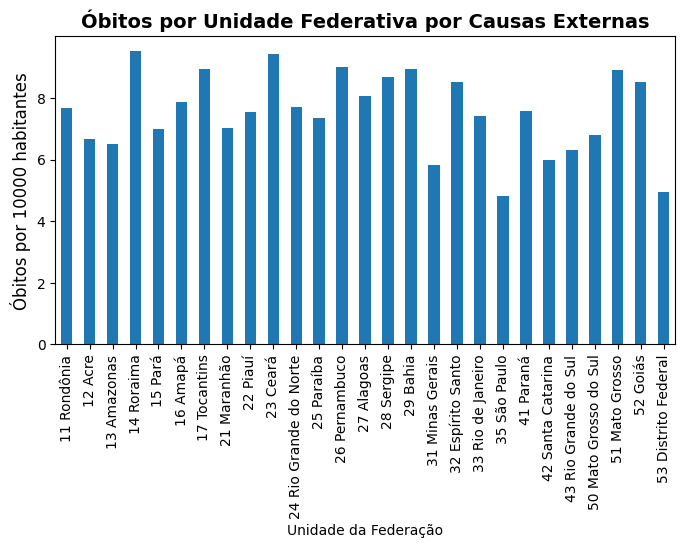

In [34]:
if 'Unidade da Federação' in obt_CaEx_2020_df.columns:
# Definindo o índice (eixo X)
  obt_CaEx_2020_df.set_index('Unidade da Federação', inplace=True)

# Criando o gráfico de barras e definindo as configurações
ax = obt_CaEx_2020_df[['Óbitos por 10000 hab']].plot(kind='bar', legend= False, figsize=(8, 4))
plt.title('Óbitos por Unidade Federativa por Causas Externas', fontsize=14, fontweight='bold')
plt.ylabel('Óbitos por 10000 habitantes', fontsize=12)

plt.show()

Com o gráfico é possível notar a variação da taxa de mortalidade entre as UF, ilustrando as diferenças regionais pontuadas anteriormente.

Para obter dados mais precisos e mais eficazes no subsídio de ações em saúde pública, pode-se analisar os números de óbito por cada uma das causas externas, nas UF de Roraima e Ceará (que apresentaram as maiores taxas de mortalidade no gráfico anterior)

In [35]:
# Importar a base de dados contendo os óbitos por causas externas nas UF Roraima e Ceará em 2020
from google.colab import files
uploaded = files.upload()

Saving Obitos_CausaExt_RR_CE_2020.csv to Obitos_CausaExt_RR_CE_2020.csv


In [36]:
obt_CaEx_RR_CE_2020_df = pd.read_csv('Obitos_CausaExt_RR_CE_2020.csv')
obt_CaEx_RR_CE_2020_df.head()


,Causa - CID-BR-10,RR,CE,Total
0,104-113 CAUSAS EXTERNAS DE MORBIDADE E MORTALI...,601,8671,9272
1,. 104 Acidentes de transporte,133,1748,1881
2,. 105 Quedas,18,397,415
3,. 106 Afogamento e submersões acidentais,40,290,330
4,". 107 Exposição à fumaça, ao fogo e às chamas",1,11,12


In [37]:
obt_CaEx_RR_CE_2020_df.tail()

,Causa - CID-BR-10,RR,CE,Total
7,. 110 Agressões,236,3984,4220
8,. 111 Eventos(fatos) cuja intenção é indetermi...,90,1263,1353
9,. 112 Intervenções legais e operações de guerra,1,8,9
10,. 113 Todas as outras causas externas,45,358,403
11,Total,601,8671,9272


In [38]:
obt_CaEx_RR_CE_2020_df.drop(columns=obt_CaEx_RR_CE_2020_df.columns[-1], inplace=True)
obt_CaEx_RR_CE_2020_df.drop(obt_CaEx_RR_CE_2020_df.index[-1], inplace=True)
obt_CaEx_RR_CE_2020_df.drop(obt_CaEx_RR_CE_2020_df.index[0], inplace=True)

In [39]:
obt_CaEx_RR_CE_2020_df.head(8)

,Causa - CID-BR-10,RR,CE
1,. 104 Acidentes de transporte,133,1748
2,. 105 Quedas,18,397
3,. 106 Afogamento e submersões acidentais,40,290
4,". 107 Exposição à fumaça, ao fogo e às chamas",1,11
5,". 108 Envenen, intoxic por ou expos a subst nociv",1,6
6,. 109 Lesões autoprovocadas voluntariamente,36,606
7,. 110 Agressões,236,3984
8,. 111 Eventos(fatos) cuja intenção é indetermi...,90,1263


Observando os dados acima, é possível notar que as principais causas externas de óbito em ambos os estados em questão foram as agressões e os acidentes de transporte.